In [1]:
import os
import sys

repo_url = "https://github.com/chahineNejm/kernels_playground"
repo_name = repo_url.split("/")[-1]
%cd /content
if os.path.exists(repo_name):
    print(f"🗑️ Wiping old '{repo_name}' to clear out local changes...")
    !rm -rf {repo_name}

print(f"📥 Cloning fresh '{repo_name}'...")
!git clone {repo_url}

repo_path = os.path.abspath(repo_name)
if repo_path not in sys.path:
    sys.path.append(repo_path)
%cd {repo_name}

req_file = "first_tests/requirements.txt"
if os.path.exists(req_file):
    print("⚙️ Installing dependencies...")
    !pip install -q -r {req_file}

%load_ext autoreload
%autoreload 2
%cd first_tests

print("\n✅ Fresh setup complete! You are now inside the 'first_tests' folder.")
!git clone https://github.com/kernel-enthusiasts/Kernel-Mode-Decomposition-1D /content/KMD
import sys
sys.path.insert(0, "/content/KMD")
from datasets import get_dataset_config_names
import gc

/content
🗑️ Wiping old 'kernels_playground' to clear out local changes...
📥 Cloning fresh 'kernels_playground'...
Cloning into 'kernels_playground'...
remote: Enumerating objects: 412, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 412 (delta 52), reused 85 (delta 34), pack-reused 291 (from 1)
Receiving objects: 100% (412/412), 88.79 MiB | 29.42 MiB/s, done.
Resolving deltas: 100% (169/169), done.
/content/kernels_playground
⚙️ Installing dependencies...
/content/kernels_playground/first_tests

✅ Fresh setup complete! You are now inside the 'first_tests' folder.
fatal: destination path '/content/KMD' already exists and is not an empty directory.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import importlib


# local utils package
from utils.config import DEFAULT_CONFIG,DATASETS, PRETRAIN_BY_DOMAIN, EVAL_BY_FREQ,EVAL_BY_DOMAIN
from utils.data import (
    load_gift_dataset, quick_peek, dataset_summary, build_examples,
    normalize_by_history,prepare_examples
)
from utils.kernels import (fit_kernel_operator, predict_kernel_operator, rmse, relative_rmse, ConvRFMKernel,
RBFKernel, DTWKernel, LinearKernel, WaveletKernel)
from utils.viz import (
    plot_series, plot_series_grid, plot_distribution,
    plot_train_test_split, plot_kernel_heatmap,
    plot_residuals, plot_metric_summary,
    plot_predictions_for_domain,report_eval,compare_results,
)
from utils.decomposition import decompose_series
from utils.pipeline import train_eval, run_all_domains,scaling_study
from utils.preprocessing import slice_pretrain, slice_domain


In [3]:
import matplotlib
matplotlib.use("Agg")

# Patch KMD_lib.py for Colab compatibility
kmd_path = "/content/KMD/KMD_lib.py"
with open(kmd_path) as f:
    src = f.read()
src = src.replace("matplotlib.use('TkAgg')", "# matplotlib.use('TkAgg')")
src = src.replace('matplotlib.use("TkAgg")', '# matplotlib.use("TkAgg")')
src = src.replace("np.float,", "float,")
src = src.replace("np.float)", "float)")
src = src.replace("np.int,", "int,")
src = src.replace("np.int)", "int)")
src = src.replace("np.complex,", "complex,")
src = src.replace("np.complex)", "complex)")
with open(kmd_path, "w") as f:
    f.write(src)

import sys
sys.path.insert(0, "/content/KMD")
import KMD_lib

## Quick dataset exploration
Use these to poke around any config before running the full pipeline.

this is quite fun because we have meta data to play with and use better afterwards

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


history: (7920,)  future: (720,)


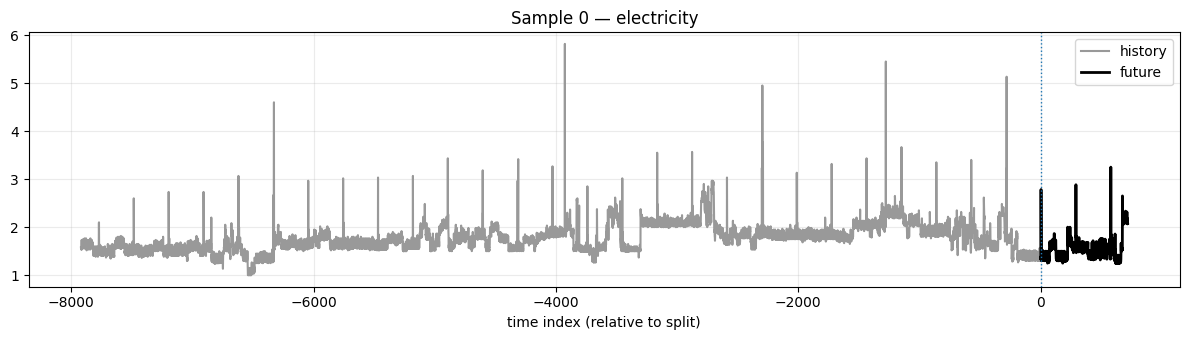

In [4]:
# Peek at one sample from parquet /eval
sample = quick_peek(index=1535, config="bitbrains_fast_storage_5T_long",dataset_name=DATASETS["eval"])
print(f"history: {sample['history'].shape}  future: {sample['future'].shape}")
plot_series(sample["history"], sample["future"], title="Sample 0 — electricity", history_context=10000,show=False)

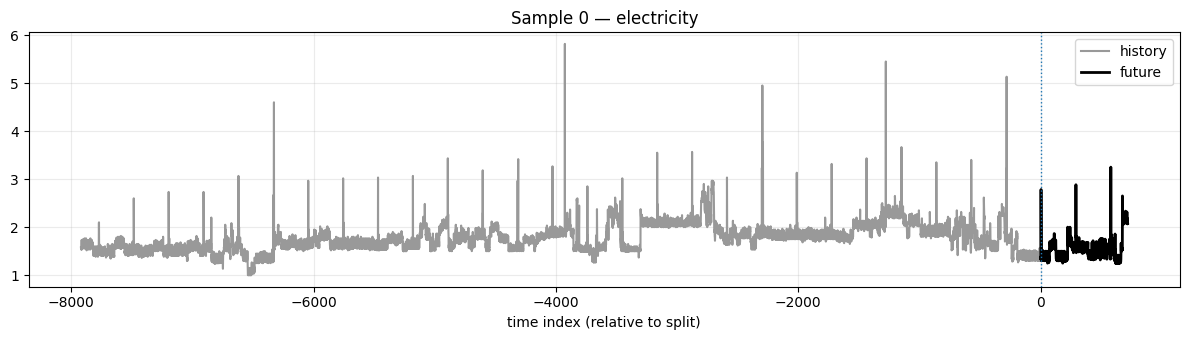

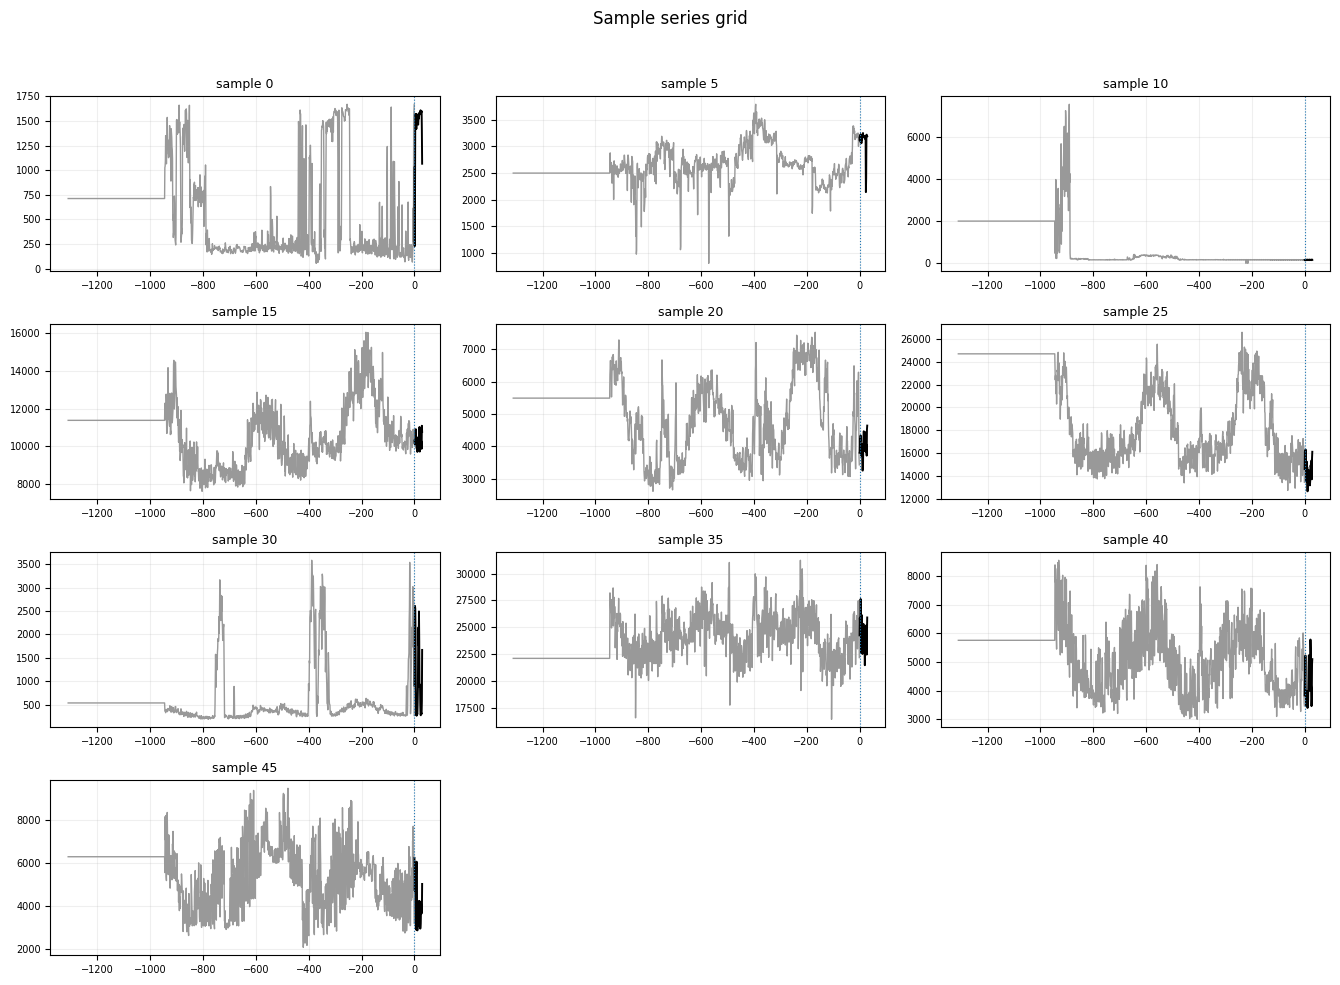

In [5]:
# Grid view of several samples
examples_preview = build_examples(config="electricity_D_short", start=0, stop =50 ,step =5,dataset_name=DATASETS["eval"])
%matplotlib inline
plot_series_grid(examples_preview)


## Full kernel‑operator pipeline

In [6]:
dataset_to_fetch = "electricity_H_long"
raw = build_examples(dataset_to_fetch, start=0,stop = 200,step= 1,dataset_name=DATASETS["eval"])
print(f"the dataset{dataset_to_fetch} is of size {len(raw)}")
lengths = [(len(e["history"]), len(e["future"])) for e in raw]
print(f"History range: {min(l[0] for l in lengths)} – {max(l[0] for l in lengths)}")
print(f"Future range:  {min(l[1] for l in lengths)} – {max(l[1] for l in lengths)}")

examples = prepare_examples(
    raw,
    history_len=None,
    future_len=None,
    min_history=500,
    min_future=100,
)
del raw

the datasetelectricity_H_long is of size 200
History range: 31464 – 34344
Future range:  720 – 720


In [7]:
examples[0].keys()

dict_keys(['sample_idx', 'history', 'future', 'history_model', 'future_model', 'history_n', 'future_n', 'mu', 'sigma', 'x_model'])

In [8]:
len(examples[0]["history_n"])

32904

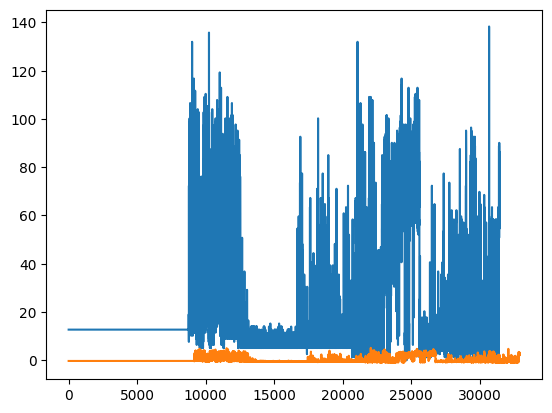

In [9]:
plt.plot(examples[0]["history"])
plt.plot(examples[0]["history_n"])

In [10]:
from sklearn.model_selection import train_test_split

total_examples = len(examples)
all_indices = range(total_examples)
print(total_examples)
# Explicitly set both train_size and test_size
my_train_indices, my_test_indices = train_test_split(
    all_indices,
    train_size=0.9,
    random_state=1 # Ensures reproducibility
)

print(f"len train:{len(my_train_indices)},len test:{len(my_test_indices)}")

200
len train:180,len test:20


In [11]:
resultRBF = train_eval(examples, kernel=RBFKernel(),train_indices=my_train_indices,test_indices=my_test_indices)

[] split: 180 train, 20 test
[] fitted: RBFKernel(lengthscale=246.7314526326748)  l=246.7315  gamma=1.00e-02
[] done - mean relRMSE=0.2748  mean MASE=2.1147


In [43]:
hist_lengths = [1000,10_000,20_000,30_000,50_000,70_000,80_000]
fut_lengths = [100,300,500,700,1000]
M = np.zeros((len(hist_lengths),len(fut_lengths)))

dataset_to_fetch = "electricity_H_long"
raw = build_examples(dataset_to_fetch, start=0,stop = 200,step= 1,dataset_name=DATASETS["eval"])

for i,his in enumerate([1000,10_000,20_000,30_000,50_000,70_000,80_000]):
  for j,fut in enumerate([100,300,500,700,1000]):
    examples = prepare_examples(
    raw,
    history_len=int(his),
    future_len=int(fut))
    resultRBF = train_eval(examples,verbose=False, kernel=RBFKernel(),train_indices=my_train_indices,test_indices=my_test_indices)
    M[i][j] = resultRBF.mean_mase


TypeError: Dimensions of C (20, 10) should be one smaller than X(5) and Y(7) while using shading='flat' see help(pcolormesh)

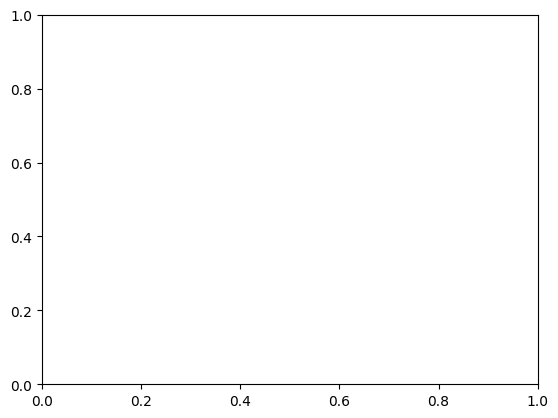

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Assuming fut_lengths is size 10 based on your error message
hist_lengths = [1000,10_000,20_000,30_000,50_000,70_000,80_000]
fut_lengths = [100,300,500,700,1000]

# 1. Added shading='auto' to fix the shape mismatch error
plt.pcolormesh(fut_lengths, hist_lengths, M, cmap='viridis', shading='auto')

# 2. Set log scales
plt.xscale('log')
plt.yscale('log')

# 3. Force normal numbers instead of scientific notation
ax = plt.gca()
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False) # Disable 10^x formatting
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

# Labels
plt.colorbar(label='Mean MASE')
plt.xlabel('Future Length')
plt.ylabel('History Length')

plt.show()

In [ ]:
plot_predictions_for_domain("energy", resultRBF.test_records, resultRBF.predictions,history_context=1000)

In [ ]:
from utils.kernels import RFMKernel

result = train_eval(
    examples,
    train_indices=my_train_indices,
    test_indices=my_test_indices,
    domain="Energy RFM",
    kernel=RFMKernel(T=3),
)

In [ ]:
plot_predictions_for_domain("energy", result.test_records, result.predictions,history_context=1000)

In [ ]:
result

In [ ]:
1/0

In [ ]:
# --- Mode 3: "coeffs" ---
# RBF on the full flattened CWT coefficient matrices.
# Richest representation but highest dimensional.
resultCWT = train_eval(examples, kernel=WaveletKernel(mode="coeffs", n_scales=64,scale_max =128, top_k=64),train_indices=my_train_indices)

In [ ]:
plot_predictions_for_domain("Traffic", resultCWT.test_records, resultCWT.predictions,history_context=1000)

In [ ]:
# auto-pick 8 log-spaced sizes
results_RBF = scaling_study(examples, kernel=RBFKernel(), domain="Traffic",test_indices = resultRBF.test_indices)

In [ ]:
import matplotlib.pyplot as plt
ns = [r.n_train for r in results_RBF]
plt.plot(ns, [r.mean_relative_rmse for r in results_RBF], marker='o', label='relRMSE')
plt.plot(ns, [r.mean_mase for r in results_RBF], marker='s', label='MASE')
plt.xlabel("n_train"); plt.legend(); plt.show()

In [ ]:
# or specify exactly which sizes
results_wavelets = scaling_study(examples, kernel=WaveletKernel(mode="coeffs", n_scales=64,scale_max =128, top_k=64),
                        domain = "Traffic",test_indices = resultRBF.test_indices)

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
ns = [r.n_train for r in results_wavelets]
plt.plot(ns, [r.mean_relative_rmse for r in results_wavelets], marker='o', label='relRMSE')
plt.plot(ns, [r.mean_mase for r in results_wavelets], marker='s', label='MASE')
plt.xlabel("n_train"); plt.legend(); plt.show()